### **Predict Calorie Expenditure — Kaggle Playground S5E5**

A clean benchmarking notebook comparing **XGBoost**, **LightGBM**, and **CatBoost** on the Calorie Expenditure dataset.  
All models share identical 5-fold CV splits for a fair, apples-to-apples comparison.

You get roughly on the top 25% the results are very much grouped so it is a question of percentages Look for future work in the last cell to advance in this challenge.

**Metric:** RMSLE (Root Mean Squared Log Error) — lower is better  
**Target:** `Calories`

> Download data from: https://www.kaggle.com/competitions/playground-series-s5e5/data

---
**Contents**
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. XGBoost
5. LightGBM
6. CatBoost
7. Model Comparison

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_log_error
from sklearn.linear_model import Ridge

import xgboost as xgb
import lightgbm as lgb
import catboost as cat
from catboost import CatBoostRegressor, Pool

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = ['#4C72B0', '#DD8452', '#55A868']
SEED    = 42
N_FOLDS = 5

def rmsle(y_true, y_pred):
    """Root Mean Squared Log Error — lower is better."""
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

print('Libraries loaded ✓')
print(f'XGBoost {xgb.__version__} | LightGBM {lgb.__version__} | CatBoost {cat.__version__}')

Libraries loaded ✓
XGBoost 3.2.0 | LightGBM 4.6.0 | CatBoost 1.2.10


In [2]:
train = pd.read_csv('./data/train.csv')
test  = pd.read_csv('./data/test.csv')

print(f'Train : {train.shape}')
print(f'Test  : {test.shape}')
train.head()

Train : (750000, 9)
Test  : (250000, 8)


,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


#### **EDA - Exploratory Data Analysis**

In [3]:
# --- Basic info -----------------------------------------------------------
print('=== dtypes ===')
print(train.dtypes)
print()
print('=== Missing values ===')
print(train.isnull().sum())

=== dtypes ===
id              int64
Sex               str
Age             int64
Height        float64
Weight        float64
Duration      float64
Heart_Rate    float64
Body_Temp     float64
Calories      float64
dtype: object

=== Missing values ===
id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64


In [4]:
train.describe().round(2)

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.00,750000.00,750000.00,750000.00,750000.00,750000.00,750000.00,750000.00
mean,374999.50,41.42,174.70,75.15,15.42,95.48,40.04,88.28
std,216506.50,15.18,12.82,13.98,8.35,9.45,0.78,62.40
min,0.00,20.00,126.00,36.00,1.00,67.00,37.10,1.00
25%,187499.75,28.00,164.00,63.00,8.00,88.00,39.60,34.00
50%,374999.50,40.00,174.00,74.00,15.00,95.00,40.30,77.00
75%,562499.25,52.00,185.00,87.00,23.00,103.00,40.70,136.00
max,749999.00,79.00,222.00,132.00,30.00,128.00,41.50,314.00


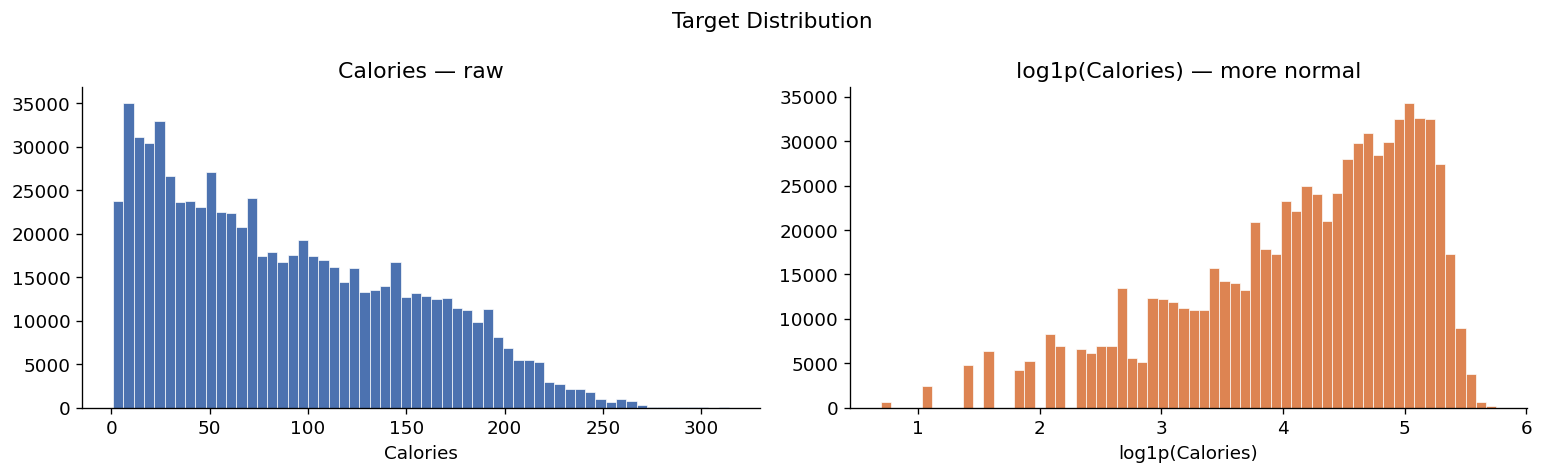

Skewness raw : 0.539
Skewness log : -0.857

→ We will train on log1p(Calories) and expm1() the predictions back.


In [5]:
# --- Target distribution --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train['Calories'], bins=60, color=PALETTE[0], edgecolor='white', linewidth=0.4)
axes[0].set_title('Calories — raw')
axes[0].set_xlabel('Calories')

axes[1].hist(np.log1p(train['Calories']), bins=60, color=PALETTE[1], edgecolor='white', linewidth=0.4)
axes[1].set_title('log1p(Calories) — more normal')
axes[1].set_xlabel('log1p(Calories)')

plt.suptitle('Target Distribution', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Skewness raw : {train["Calories"].skew():.3f}')
print(f'Skewness log : {np.log1p(train["Calories"]).skew():.3f}')
print()
print('→ We will train on log1p(Calories) and expm1() the predictions back.')

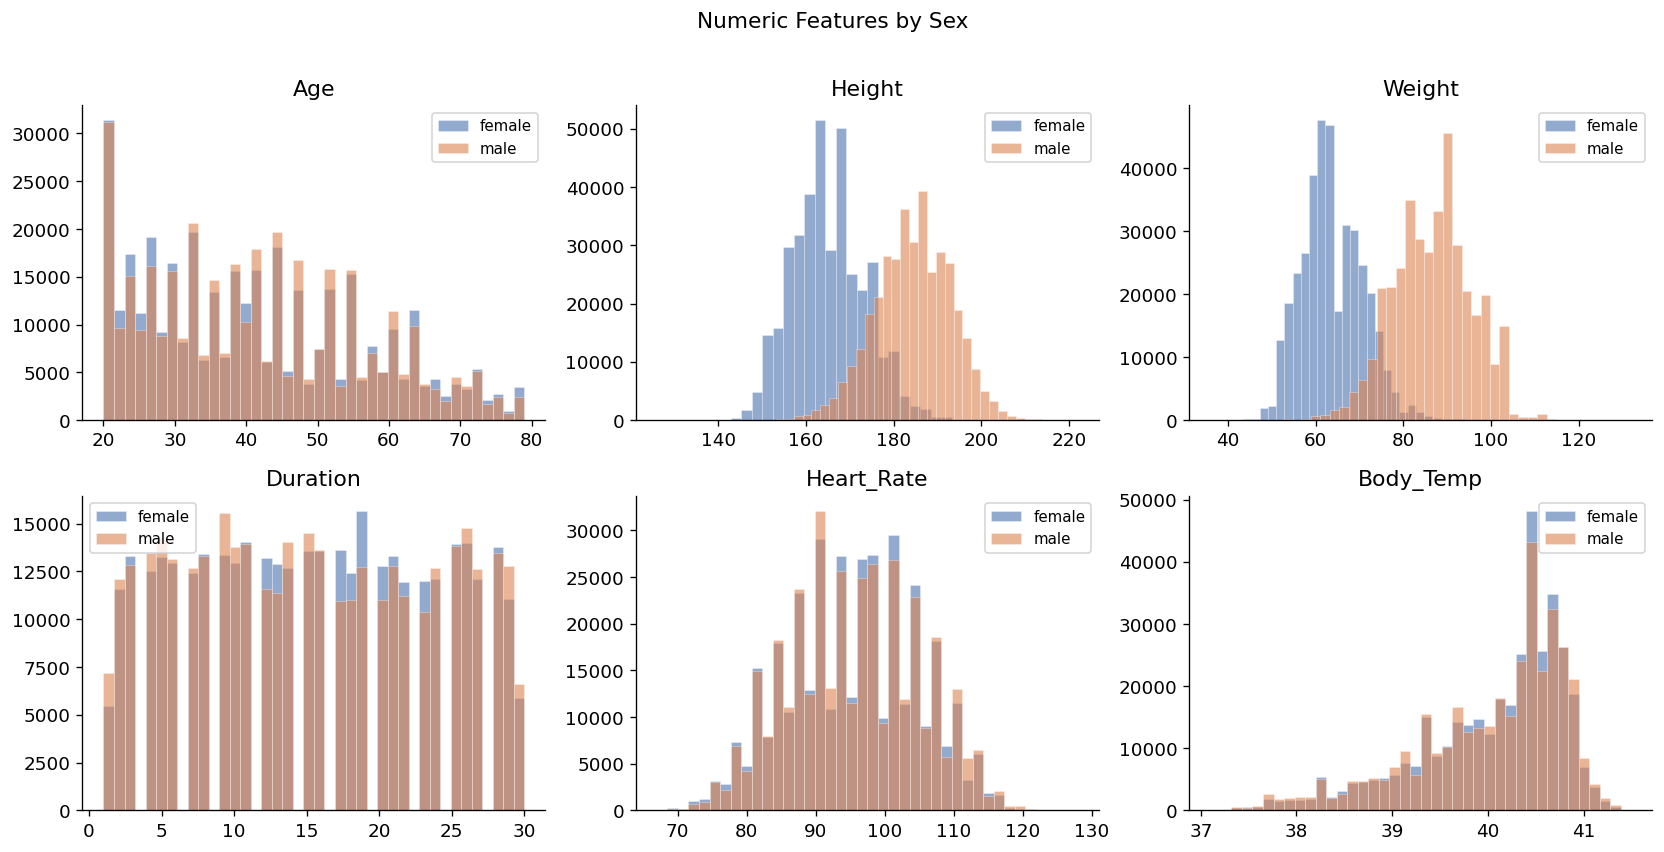

In [6]:
# --- Numeric feature distributions by Sex --------------------------------
num_cols = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, num_cols):
    for i, (sex, grp) in enumerate(train.groupby('Sex')):
        ax.hist(grp[col], bins=40, alpha=0.6, label=sex,
                color=PALETTE[i], edgecolor='white', linewidth=0.3)
    ax.set_title(col)
    ax.legend(fontsize=9)

plt.suptitle('Numeric Features by Sex', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

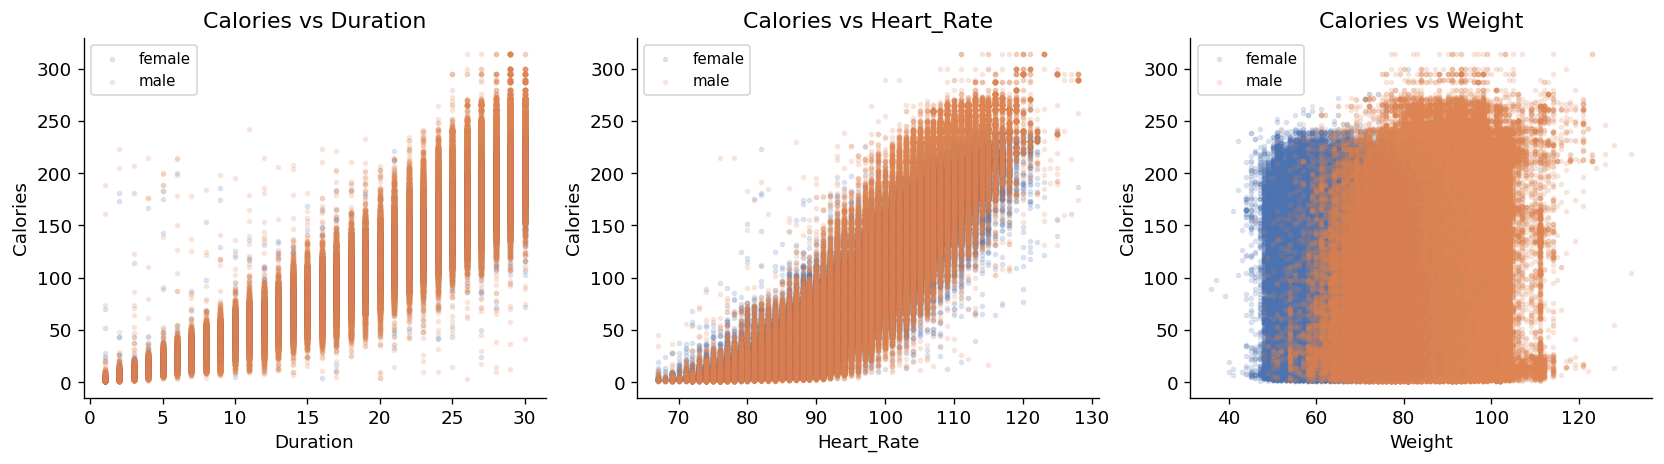

In [7]:
# --- Calories vs key predictors -------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['Duration', 'Heart_Rate', 'Weight']):
    for i, (sex, grp) in enumerate(train.groupby('Sex')):
        ax.scatter(grp[col], grp['Calories'], alpha=0.15, s=6,
                   color=PALETTE[i], label=sex)
    ax.set_xlabel(col)
    ax.set_ylabel('Calories')
    ax.set_title(f'Calories vs {col}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

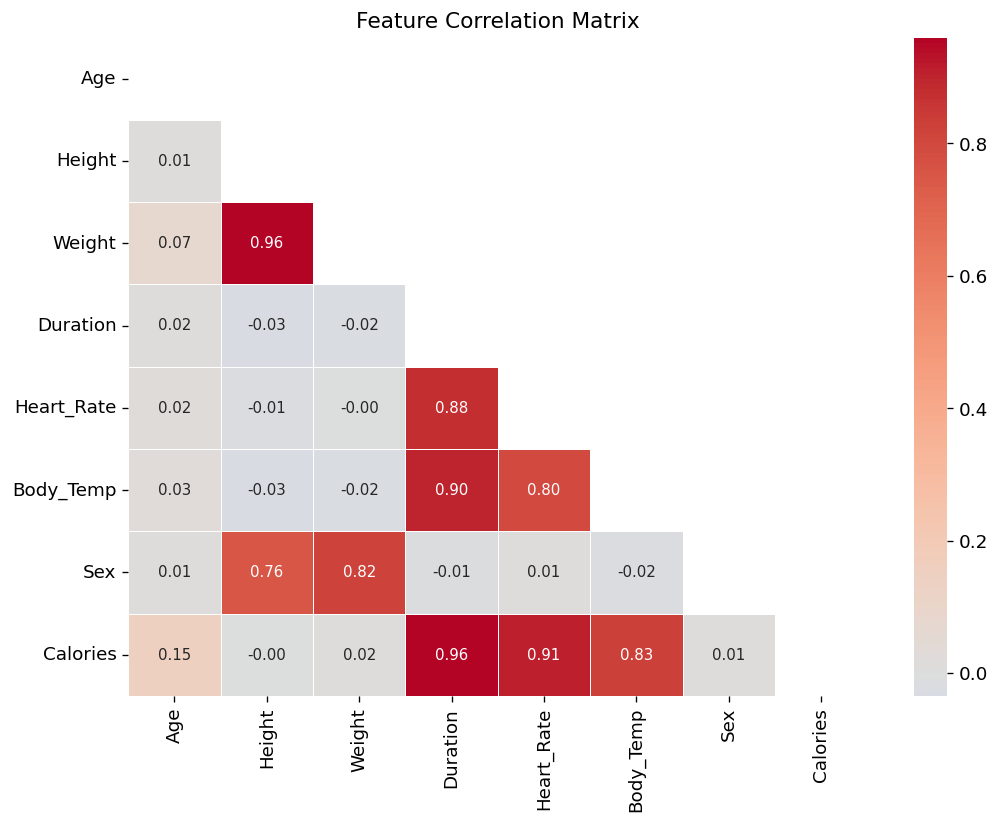

In [8]:
# --- Correlation heatmap --------------------------------------------------
train_enc = train.copy()
train_enc['Sex'] = (train_enc['Sex'] == 'male').astype(int)

corr = train_enc[num_cols + ['Sex', 'Calories']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

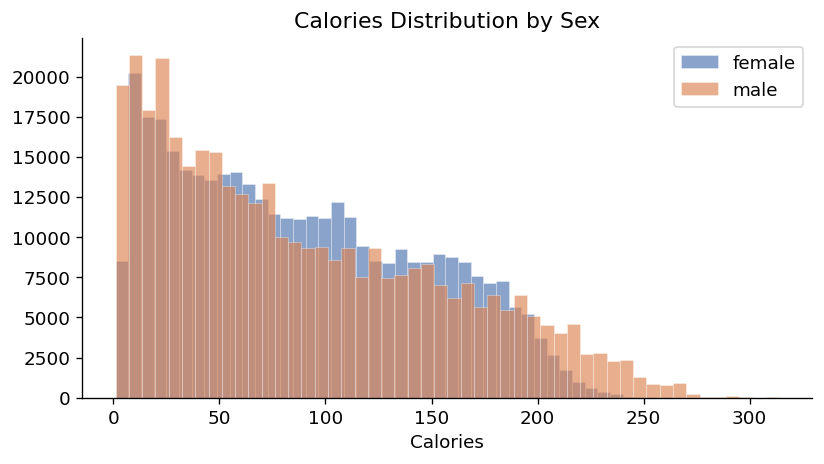

           count  mean   std  min   25%   50%    75%    max
Sex                                                        
female  375721.0  87.5  57.9  1.0  37.0  80.0  133.0  300.0
male    374279.0  89.0  66.6  1.0  31.0  73.0  138.0  314.0


In [9]:
# --- Sex split on Calories ------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
for i, (sex, grp) in enumerate(train.groupby('Sex')):
    ax.hist(grp['Calories'], bins=50, alpha=0.65,
            label=sex, color=PALETTE[i], edgecolor='white', linewidth=0.3)
ax.set_title('Calories Distribution by Sex')
ax.set_xlabel('Calories')
ax.legend()
plt.tight_layout()
plt.show()

print(train.groupby('Sex')['Calories'].describe().round(1))

#### **Feature Engineering**

We keep it light — the goal is to compare models on roughly equal footing.  
We want to compare the three Boosting models and we are not really concerned on the Feature Engineering.<br>
A handful of physiology-informed features that boosting trees can't trivially construct:

| Feature | Rationale |
|---|---|
| `BMI` | Body Mass Index — normalises weight for height |
| `Max_HR` | Age-predicted max heart rate (220 − Age) |
| `HR_Intensity` | Heart Rate / Max_HR — relative exercise intensity |
| `Work` | Heart Rate × Duration — proxy for total cardiovascular effort |
| `Weight_x_Duration` | Mechanical work proxy |
| `Temp_Delta` | Body temp deviation from resting (~37°C) |

In [10]:
def build_features(df):
    df = df.copy()

    # Encode Sex
    df['Sex_enc'] = (df['Sex'] == 'male').astype(np.int8)

    # Body Mass Index
    df['BMI'] = df['Weight'] / (df['Height'] / 100) ** 2

    # Age-predicted max heart rate (Haskell & Fox formula)
    df['Max_HR'] = 220 - df['Age']

    # Fraction of max HR — exercise intensity
    df['HR_Intensity'] = df['Heart_Rate'] / df['Max_HR']

    # Total cardiovascular work
    df['Work'] = df['Heart_Rate'] * df['Duration']

    # Mechanical work proxy
    df['Weight_x_Duration'] = df['Weight'] * df['Duration']

    # Temperature rise above resting
    df['Temp_Delta'] = df['Body_Temp'] - 37.0

    # Interaction: Heart Rate × Body Temp
    df['HR_x_Temp'] = df['Heart_Rate'] * df['Body_Temp']

    return df


train_fe = build_features(train)
test_fe  = build_features(test)

FEATURE_COLS = [
    'Sex_enc', 'Age', 'Height', 'Weight', 'Duration',
    'Heart_Rate', 'Body_Temp',
    'BMI', 'Max_HR', 'HR_Intensity', 'Work',
    'Weight_x_Duration', 'Temp_Delta', 'HR_x_Temp',
]
TARGET = 'Calories'

print(f'{len(FEATURE_COLS)} features: {FEATURE_COLS}')
train_fe[FEATURE_COLS].describe().round(2)

14 features: ['Sex_enc', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'BMI', 'Max_HR', 'HR_Intensity', 'Work', 'Weight_x_Duration', 'Temp_Delta', 'HR_x_Temp']


,Sex_enc,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,BMI,Max_HR,HR_Intensity,Work,Weight_x_Duration,Temp_Delta,HR_x_Temp
count,750000.0,750000.00,750000.00,750000.00,750000.00,750000.00,750000.00,750000.00,750000.00,750000.00,750000.00,750000.00,750000.00,750000.00
mean,0.5,41.42,174.70,75.15,15.42,95.48,40.04,24.37,178.58,0.54,1541.56,1156.39,3.04,3828.69
std,0.5,15.18,12.82,13.98,8.35,9.45,0.78,1.51,15.18,0.07,932.45,672.88,0.78,437.97
min,0.0,20.00,126.00,36.00,1.00,67.00,37.10,12.38,141.00,0.34,67.00,45.00,0.10,2485.70
25%,0.0,28.00,164.00,63.00,8.00,88.00,39.60,23.26,168.00,0.49,728.00,600.00,2.60,3497.40
50%,0.0,40.00,174.00,74.00,15.00,95.00,40.30,24.39,180.00,0.53,1455.00,1105.00,3.30,3838.00
75%,1.0,52.00,185.00,87.00,23.00,103.00,40.70,25.49,192.00,0.58,2323.00,1633.00,3.70,4171.50
max,1.0,79.00,222.00,132.00,30.00,128.00,41.50,46.44,200.00,0.91,3840.00,3780.00,4.50,5286.40


In [11]:
# --- Prepare arrays and shared CV folds ----------------------------------
X      = train_fe[FEATURE_COLS].values
y      = train_fe[TARGET].values
X_test = test_fe[FEATURE_COLS].values

kf    = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
FOLDS = list(kf.split(X, y))

print(f'{N_FOLDS}-fold CV ready.')
print(f'  Train fold size : ~{len(FOLDS[0][0])}')
print(f'  Val   fold size : ~{len(FOLDS[0][1])}')

5-fold CV ready.
  Train fold size : ~600000
  Val   fold size : ~150000


#### **XGBoost**

**Parameter rationale**
- `n_estimators=1000` + `early_stopping_rounds=50` — let val loss decide when to stop
- `max_depth=6` — classic safe default; level-wise trees
- `learning_rate=0.05` — low enough that early stopping has room to breathe
- `subsample=0.8`, `colsample_bytree=0.8` — mild stochastic regularisation
- `reg_lambda=1.0` — L2 regularisation (XGBoost default)
- Train on `log1p(y)` → predictions `expm1()`'d back → directly minimises RMSLE

In [12]:
XGB_PARAMS = dict(
    n_estimators          = 1000,
    learning_rate         = 0.05,
    max_depth             = 6,
    subsample             = 0.80,
    colsample_bytree      = 0.80,
    reg_lambda            = 1.0,
    reg_alpha             = 0.0,
    min_child_weight      = 5,
    early_stopping_rounds = 50,   # XGBoost ≥3.0: set in constructor
    objective             = 'reg:squarederror',
    eval_metric           = 'rmse',
    random_state          = SEED,
    n_jobs                = -1,
    verbosity             = 0,
)

xgb_oof        = np.zeros(len(X))
xgb_test_preds = np.zeros(len(X_test))
xgb_scores     = []
xgb_best_iters = []

for fold, (tr_idx, val_idx) in enumerate(FOLDS):
    X_tr,  X_val  = X[tr_idx],  X[val_idx]
    y_tr,  y_val  = np.log1p(y[tr_idx]), np.log1p(y[val_idx])

    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    val_pred = np.expm1(model.predict(X_val))
    xgb_oof[val_idx]    = val_pred
    xgb_test_preds     += np.expm1(model.predict(X_test)) / N_FOLDS

    score = rmsle(y[val_idx], val_pred)
    xgb_scores.append(score)
    xgb_best_iters.append(model.best_iteration)
    print(f'  Fold {fold+1}  RMSLE={score:.5f}  best_iter={model.best_iteration}')

xgb_cv = np.mean(xgb_scores)
print(f'\nXGBoost CV RMSLE : {xgb_cv:.5f} ± {np.std(xgb_scores):.5f}')

  Fold 1  RMSLE=0.05996  best_iter=718
  Fold 2  RMSLE=0.06052  best_iter=767
  Fold 3  RMSLE=0.05993  best_iter=623
  Fold 4  RMSLE=0.06016  best_iter=734
  Fold 5  RMSLE=0.06030  best_iter=339

XGBoost CV RMSLE : 0.06018 ± 0.00022


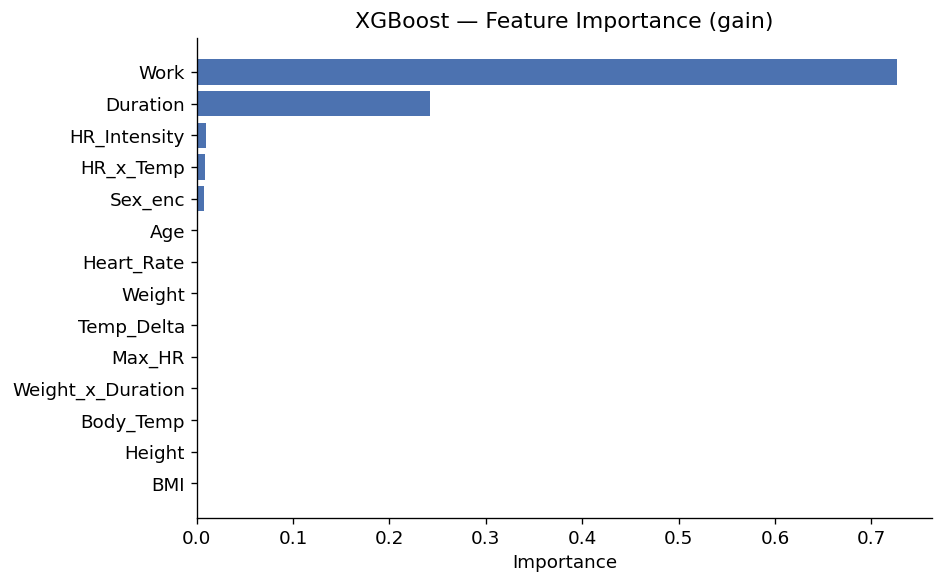

In [13]:
# --- XGBoost feature importance ------------------------------------------
# Refit on full train using mean best iteration
xgb_full_params = {k: v for k, v in XGB_PARAMS.items() if k != 'early_stopping_rounds'}
xgb_full_params['n_estimators'] = int(np.mean(xgb_best_iters))
xgb_full = xgb.XGBRegressor(**xgb_full_params)
xgb_full.fit(X, np.log1p(y), verbose=False)

xgb_imp = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': xgb_full.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(xgb_imp['feature'], xgb_imp['importance'], color=PALETTE[0])
ax.set_title('XGBoost — Feature Importance (gain)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

#### **LightGBM**

**Parameter rationale**
- `num_leaves=127` — LGB uses leaf-wise growth; this is the primary complexity knob
- `max_depth=-1` — unconstrained depth; `num_leaves` controls it instead
- `learning_rate=0.05` — identical to XGB for a fair comparison
- `feature_fraction=0.8`, `bagging_fraction=0.8` — equivalent to XGB's colsample/subsample
- `min_child_samples=20` — prevents tiny leaves
- `lambda_l2=1.0` — mirrors XGB's reg_lambda

In [14]:
LGB_PARAMS = dict(
    n_estimators      = 1000,
    learning_rate     = 0.05,
    num_leaves        = 127,
    max_depth         = -1,       # unlimited; controlled by num_leaves
    feature_fraction  = 0.80,
    bagging_fraction  = 0.80,
    bagging_freq      = 1,
    min_child_samples = 20,
    lambda_l2         = 1.0,
    lambda_l1         = 0.0,
    objective         = 'regression',
    metric            = 'rmse',
    random_state      = SEED,
    n_jobs            = -1,
    verbose           = -1,
)

lgb_oof        = np.zeros(len(X))
lgb_test_preds = np.zeros(len(X_test))
lgb_scores     = []
lgb_best_iters = []

for fold, (tr_idx, val_idx) in enumerate(FOLDS):
    X_tr,  X_val  = X[tr_idx],  X[val_idx]
    y_tr,  y_val  = np.log1p(y[tr_idx]), np.log1p(y[val_idx])

    model = lgb.LGBMRegressor(**LGB_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(-1),
        ],
    )

    val_pred = np.expm1(model.predict(X_val))
    lgb_oof[val_idx]    = val_pred
    lgb_test_preds     += np.expm1(model.predict(X_test)) / N_FOLDS

    score = rmsle(y[val_idx], val_pred)
    lgb_scores.append(score)
    lgb_best_iters.append(model.best_iteration_)
    print(f'  Fold {fold+1}  RMSLE={score:.5f}  best_iter={model.best_iteration_}')

lgb_cv = np.mean(lgb_scores)
print(f'\nLightGBM CV RMSLE : {lgb_cv:.5f} ± {np.std(lgb_scores):.5f}')

  Fold 1  RMSLE=0.05983  best_iter=289
  Fold 2  RMSLE=0.06061  best_iter=300
  Fold 3  RMSLE=0.05998  best_iter=278
  Fold 4  RMSLE=0.06036  best_iter=370
  Fold 5  RMSLE=0.05992  best_iter=200

LightGBM CV RMSLE : 0.06014 ± 0.00030


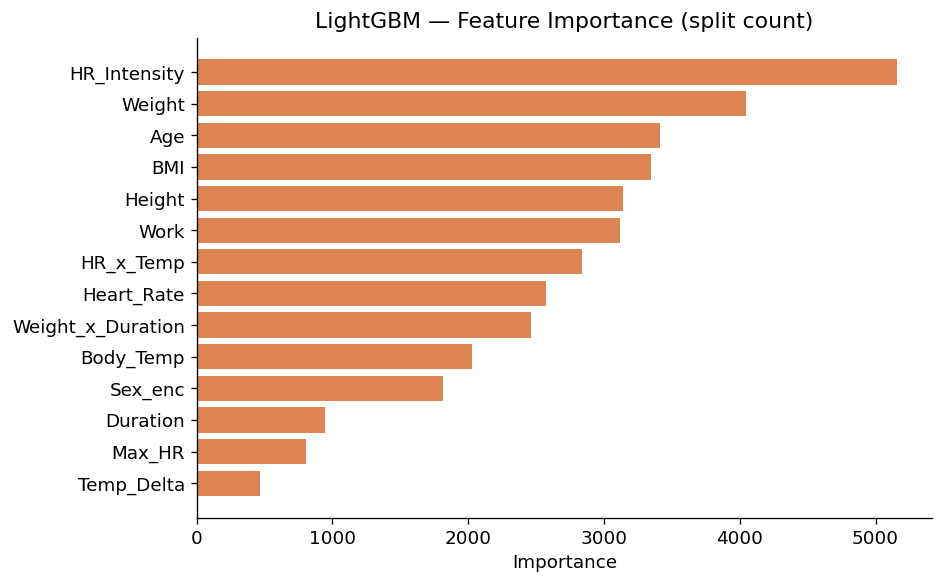

In [15]:
# --- LightGBM feature importance -----------------------------------------
lgb_full = lgb.LGBMRegressor(**{**LGB_PARAMS, 'n_estimators': int(np.mean(lgb_best_iters))})
lgb_full.fit(X, np.log1p(y))

lgb_imp = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': lgb_full.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(lgb_imp['feature'], lgb_imp['importance'], color=PALETTE[1])
ax.set_title('LightGBM — Feature Importance (split count)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

#### **CatBoost**

**Parameter rationale**
- `iterations=1000` + `early_stopping_rounds=50`
- `depth=6` — CatBoost builds symmetric (oblivious) trees; depth=6 is roughly equivalent in complexity to XGB's max_depth=6
- `learning_rate=0.05` — same as the others
- `l2_leaf_reg=3.0` — CatBoost's L2; slightly higher default is typical
- `subsample=0.8` — row sampling
- `rsm=0.8` — Random Subspace Method = feature fraction

In [16]:
CB_PARAMS = dict(
    iterations       = 1000,
    learning_rate    = 0.05,
    depth            = 6,
    l2_leaf_reg      = 3.0,
    subsample        = 0.80,
    rsm              = 0.80,      # random subspace method = colsample
    min_data_in_leaf = 20,
    loss_function    = 'RMSE',
    eval_metric      = 'RMSE',
    random_seed      = SEED,
    thread_count     = -1,
    verbose          = False,
)

cb_oof        = np.zeros(len(X))
cb_test_preds = np.zeros(len(X_test))
cb_scores     = []
cb_best_iters = []

for fold, (tr_idx, val_idx) in enumerate(FOLDS):
    X_tr,  X_val  = X[tr_idx],  X[val_idx]
    y_tr,  y_val  = np.log1p(y[tr_idx]), np.log1p(y[val_idx])

    train_pool = Pool(X_tr, y_tr, feature_names=FEATURE_COLS)
    val_pool   = Pool(X_val, y_val, feature_names=FEATURE_COLS)

    model = CatBoostRegressor(**CB_PARAMS)
    model.fit(
        train_pool,
        eval_set=val_pool,
        early_stopping_rounds=50,
    )

    val_pred = np.expm1(model.predict(X_val))
    cb_oof[val_idx]    = val_pred
    cb_test_preds     += np.expm1(model.predict(X_test)) / N_FOLDS

    score = rmsle(y[val_idx], val_pred)
    cb_scores.append(score)
    cb_best_iters.append(model.best_iteration_)
    print(f'  Fold {fold+1}  RMSLE={score:.5f}  best_iter={model.best_iteration_}')

cb_cv = np.mean(cb_scores)
print(f'\nCatBoost CV RMSLE : {cb_cv:.5f} ± {np.std(cb_scores):.5f}')

  Fold 1  RMSLE=0.05998  best_iter=999
  Fold 2  RMSLE=0.06023  best_iter=999
  Fold 3  RMSLE=0.05997  best_iter=999
  Fold 4  RMSLE=0.06010  best_iter=993
  Fold 5  RMSLE=0.05966  best_iter=999

CatBoost CV RMSLE : 0.05999 ± 0.00019


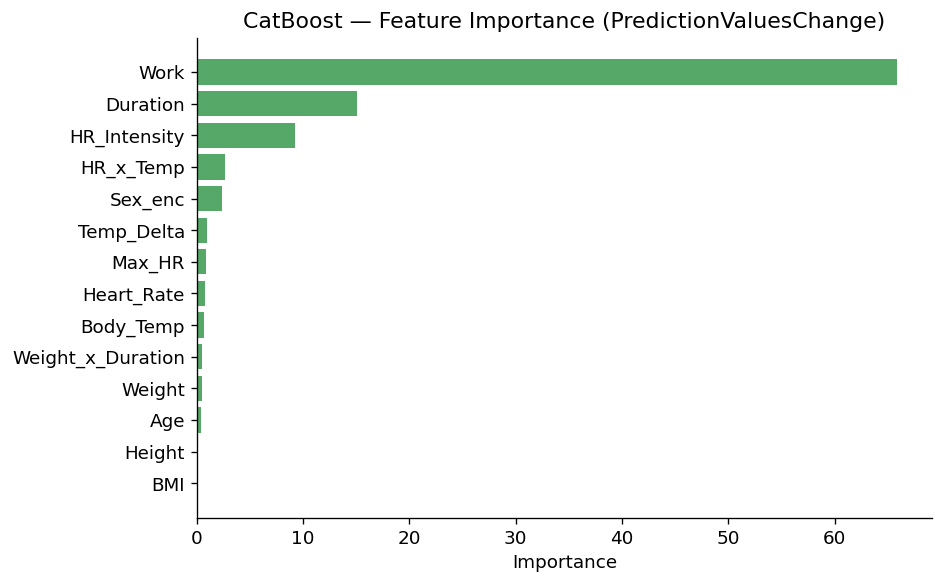

In [17]:
# --- CatBoost feature importance -----------------------------------------
cb_full = CatBoostRegressor(**{**CB_PARAMS, 'iterations': int(np.mean(cb_best_iters))})
cb_full.fit(Pool(X, np.log1p(y), feature_names=FEATURE_COLS))

cb_imp = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': cb_full.get_feature_importance()
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(cb_imp['feature'], cb_imp['importance'], color=PALETTE[2])
ax.set_title('CatBoost — Feature Importance (PredictionValuesChange)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

#### **Model Diversity and CatBoost Tuning**

The original stack used three strong but highly correlated learners.  
Here we add deliberately different model shapes and seeds so the final blend has more independent errors to exploit.

CatBoost gets the main tuning pass: lower learning rate, more iterations, longer early stopping, and multiple depths.


In [18]:
# --- Diverse model variants ---------------------------------------------
def predict_log_model(model, X_val, X_test):
    """Return clipped original-scale validation and test predictions."""
    val_pred = np.clip(np.expm1(model.predict(X_val)), 0, None)
    test_pred = np.clip(np.expm1(model.predict(X_test)), 0, None)
    return val_pred, test_pred


def train_xgb_variant(name, params):
    oof = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    scores = []
    best_iters = []

    for fold, (tr_idx, val_idx) in enumerate(FOLDS):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = np.log1p(y[tr_idx]), np.log1p(y[val_idx])

        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

        val_pred, test_pred = predict_log_model(model, X_val, X_test)
        oof[val_idx] = val_pred
        test_preds += test_pred / N_FOLDS

        score = rmsle(y[val_idx], val_pred)
        scores.append(score)
        best_iters.append(model.best_iteration)
        print(f'  {name} | Fold {fold + 1} RMSLE={score:.5f} best_iter={model.best_iteration}')

    print(f'{name} CV RMSLE: {np.mean(scores):.5f} +/- {np.std(scores):.5f}')
    return {'name': name, 'family': 'XGBoost', 'oof': oof, 'test': test_preds, 'scores': scores, 'best_iters': best_iters}


def train_lgb_variant(name, params):
    oof = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    scores = []
    best_iters = []

    for fold, (tr_idx, val_idx) in enumerate(FOLDS):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = np.log1p(y[tr_idx]), np.log1p(y[val_idx])

        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(100, verbose=False),
                lgb.log_evaluation(-1),
            ],
        )

        val_pred, test_pred = predict_log_model(model, X_val, X_test)
        oof[val_idx] = val_pred
        test_preds += test_pred / N_FOLDS

        score = rmsle(y[val_idx], val_pred)
        scores.append(score)
        best_iters.append(model.best_iteration_)
        print(f'  {name} | Fold {fold + 1} RMSLE={score:.5f} best_iter={model.best_iteration_}')

    print(f'{name} CV RMSLE: {np.mean(scores):.5f} +/- {np.std(scores):.5f}')
    return {'name': name, 'family': 'LightGBM', 'oof': oof, 'test': test_preds, 'scores': scores, 'best_iters': best_iters}


def train_cb_variant(name, params):
    oof = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    scores = []
    best_iters = []

    for fold, (tr_idx, val_idx) in enumerate(FOLDS):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = np.log1p(y[tr_idx]), np.log1p(y[val_idx])

        train_pool = Pool(X_tr, y_tr, feature_names=FEATURE_COLS)
        val_pool = Pool(X_val, y_val, feature_names=FEATURE_COLS)

        model = CatBoostRegressor(**params)
        model.fit(
            train_pool,
            eval_set=val_pool,
            early_stopping_rounds=150,
            use_best_model=True,
        )

        val_pred, test_pred = predict_log_model(model, X_val, X_test)
        oof[val_idx] = val_pred
        test_preds += test_pred / N_FOLDS

        score = rmsle(y[val_idx], val_pred)
        scores.append(score)
        best_iters.append(model.best_iteration_)
        print(f'  {name} | Fold {fold + 1} RMSLE={score:.5f} best_iter={model.best_iteration_}')

    print(f'{name} CV RMSLE: {np.mean(scores):.5f} +/- {np.std(scores):.5f}')
    return {'name': name, 'family': 'CatBoost', 'oof': oof, 'test': test_preds, 'scores': scores, 'best_iters': best_iters}


model_results = [
    {'name': 'XGB baseline d6', 'family': 'XGBoost', 'oof': xgb_oof, 'test': xgb_test_preds, 'scores': xgb_scores, 'best_iters': xgb_best_iters},
    {'name': 'LGB baseline leaves127', 'family': 'LightGBM', 'oof': lgb_oof, 'test': lgb_test_preds, 'scores': lgb_scores, 'best_iters': lgb_best_iters},
    {'name': 'CB baseline d6', 'family': 'CatBoost', 'oof': cb_oof, 'test': cb_test_preds, 'scores': cb_scores, 'best_iters': cb_best_iters},
]

XGB_DIVERSE_CONFIGS = [
    ('XGB shallow d4', {
        **XGB_PARAMS,
        'n_estimators': 2000,
        'learning_rate': 0.03,
        'max_depth': 4,
        'min_child_weight': 20,
        'subsample': 0.90,
        'colsample_bytree': 0.90,
        'reg_lambda': 2.5,
        'reg_alpha': 0.05,
        'early_stopping_rounds': 100,
        'random_state': SEED + 101,
    }),
    ('XGB deep d8', {
        **XGB_PARAMS,
        'n_estimators': 1800,
        'learning_rate': 0.03,
        'max_depth': 8,
        'min_child_weight': 10,
        'subsample': 0.75,
        'colsample_bytree': 0.75,
        'reg_lambda': 4.0,
        'reg_alpha': 0.10,
        'early_stopping_rounds': 100,
        'random_state': SEED + 102,
    }),
]

LGB_DIVERSE_CONFIGS = [
    ('LGB regularized leaves63', {
        **LGB_PARAMS,
        'n_estimators': 2200,
        'learning_rate': 0.03,
        'num_leaves': 63,
        'max_depth': 8,
        'min_child_samples': 60,
        'feature_fraction': 0.90,
        'bagging_fraction': 0.90,
        'lambda_l2': 4.0,
        'lambda_l1': 0.05,
        'extra_trees': True,
        'random_state': SEED + 201,
    }),
    ('LGB wide leaves255', {
        **LGB_PARAMS,
        'n_estimators': 2200,
        'learning_rate': 0.03,
        'num_leaves': 255,
        'max_depth': -1,
        'min_child_samples': 45,
        'feature_fraction': 0.75,
        'bagging_fraction': 0.75,
        'lambda_l2': 6.0,
        'lambda_l1': 0.10,
        'random_state': SEED + 202,
    }),
]

CB_TUNED_CONFIGS = [
    ('CB tuned d4', {
        **CB_PARAMS,
        'iterations': 3000,
        'learning_rate': 0.035,
        'depth': 4,
        'l2_leaf_reg': 8.0,
        'subsample': 0.90,
        'rsm': 0.95,
        'min_data_in_leaf': 40,
        'random_strength': 0.5,
        'bootstrap_type': 'Bernoulli',
        'random_seed': SEED + 301,
    }),
    ('CB tuned d6', {
        **CB_PARAMS,
        'iterations': 3000,
        'learning_rate': 0.025,
        'depth': 6,
        'l2_leaf_reg': 6.0,
        'subsample': 0.85,
        'rsm': 0.90,
        'min_data_in_leaf': 30,
        'random_strength': 0.75,
        'bootstrap_type': 'Bernoulli',
        'random_seed': SEED + 302,
    }),
    ('CB tuned d8', {
        **CB_PARAMS,
        'iterations': 3000,
        'learning_rate': 0.025,
        'depth': 8,
        'l2_leaf_reg': 8.0,
        'subsample': 0.80,
        'rsm': 0.85,
        'min_data_in_leaf': 40,
        'random_strength': 1.0,
        'bootstrap_type': 'Bernoulli',
        'random_seed': SEED + 303,
    }),
]

for name, params in XGB_DIVERSE_CONFIGS:
    model_results.append(train_xgb_variant(name, params))

for name, params in LGB_DIVERSE_CONFIGS:
    model_results.append(train_lgb_variant(name, params))

for name, params in CB_TUNED_CONFIGS:
    model_results.append(train_cb_variant(name, params))

model_names = [m['name'] for m in model_results]
oof_matrix = np.column_stack([m['oof'] for m in model_results])
test_matrix = np.column_stack([m['test'] for m in model_results])
model_palette = sns.color_palette('tab10', n_colors=len(model_results)).as_hex()

print(f'\nTotal models available for ensembling: {len(model_results)}')


  XGB shallow d4 | Fold 1 RMSLE=0.06012 best_iter=1987
  XGB shallow d4 | Fold 2 RMSLE=0.06059 best_iter=1998
  XGB shallow d4 | Fold 3 RMSLE=0.06003 best_iter=1997
  XGB shallow d4 | Fold 4 RMSLE=0.06036 best_iter=1999
  XGB shallow d4 | Fold 5 RMSLE=0.06002 best_iter=1984
XGB shallow d4 CV RMSLE: 0.06022 +/- 0.00022
  XGB deep d8 | Fold 1 RMSLE=0.05948 best_iter=568
  XGB deep d8 | Fold 2 RMSLE=0.06020 best_iter=738
  XGB deep d8 | Fold 3 RMSLE=0.05960 best_iter=675
  XGB deep d8 | Fold 4 RMSLE=0.05999 best_iter=636
  XGB deep d8 | Fold 5 RMSLE=0.05962 best_iter=488
XGB deep d8 CV RMSLE: 0.05978 +/- 0.00027
  LGB regularized leaves63 | Fold 1 RMSLE=0.06026 best_iter=2200
  LGB regularized leaves63 | Fold 2 RMSLE=0.06125 best_iter=2200
  LGB regularized leaves63 | Fold 3 RMSLE=0.06034 best_iter=2200
  LGB regularized leaves63 | Fold 4 RMSLE=0.06084 best_iter=2200
  LGB regularized leaves63 | Fold 5 RMSLE=0.06013 best_iter=2200
LGB regularized leaves63 CV RMSLE: 0.06056 +/- 0.00042
  L

#### **Model Comparison**

In [20]:
# --- Summary table --------------------------------------------------------
models = model_names
cv_means = [rmsle(y, m['oof']) for m in model_results]
cv_stds = [np.std(m['scores']) for m in model_results]
avg_iters = [int(np.mean(m['best_iters'])) for m in model_results]
fold_scores = [m['scores'] for m in model_results]

summary = pd.DataFrame({
    'Family': [m['family'] for m in model_results],
    'CV RMSLE': cv_means,
    'Std': cv_stds,
    'Avg best iter': avg_iters,
}, index=models).sort_values('CV RMSLE')

print('=== Cross-Validation Results ===')
display(summary.style.format({'CV RMSLE': '{:.5f}', 'Std': '{:.5f}'}))

best_model = summary.index[0]
print(f'\nBest single model: {best_model} | RMSLE={summary.loc[best_model, "CV RMSLE"]:.5f}')


=== Cross-Validation Results ===


,Family,CV RMSLE,Std,Avg best iter
CB tuned d8,CatBoost,0.05961,0.00030,2924
CB tuned d6,CatBoost,0.05973,0.00025,2904
XGB deep d8,XGBoost,0.05978,0.00027,621
CB tuned d4,CatBoost,0.05999,0.00029,2997
CB baseline d6,CatBoost,0.05999,0.00019,997
LGB wide leaves255,LightGBM,0.06011,0.00045,382
LGB baseline leaves127,LightGBM,0.06014,0.00030,287
XGB baseline d6,XGBoost,0.06018,0.00022,636
XGB shallow d4,XGBoost,0.06022,0.00022,1993
LGB regularized leaves63,LightGBM,0.06057,0.00042,2200



Best single model: CB tuned d8 | RMSLE=0.05961


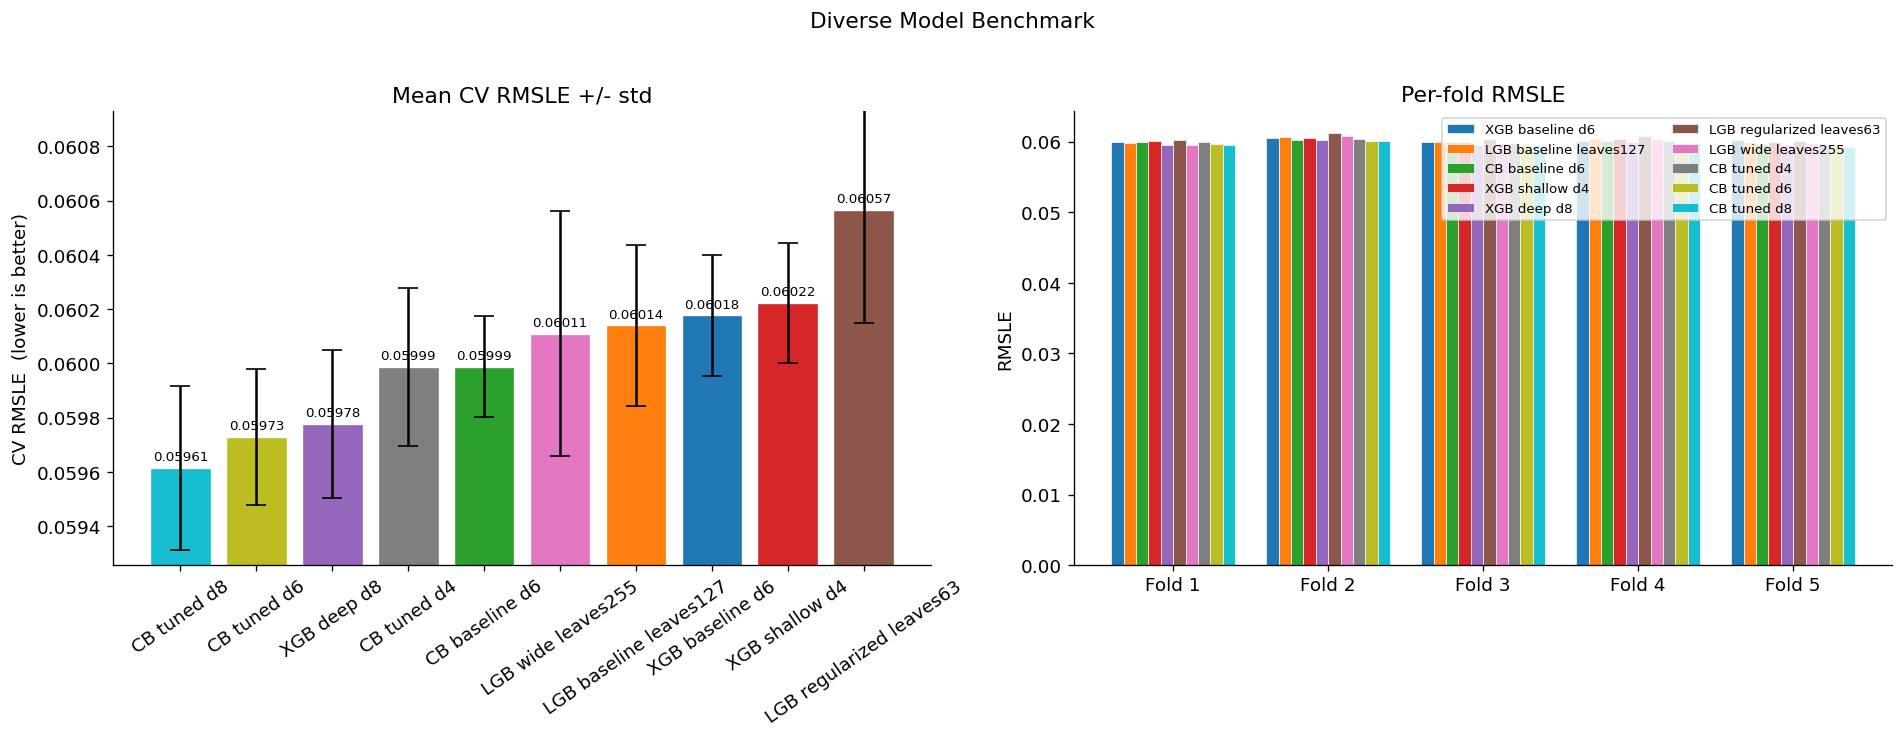

In [21]:
# --- Bar chart: mean CV RMSLE + per-fold breakdown ----------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ordered_summary = summary.sort_values('CV RMSLE')
ordered_models = ordered_summary.index.tolist()
ordered_colors = [model_palette[models.index(name)] for name in ordered_models]

bars = axes[0].bar(
    ordered_models,
    ordered_summary['CV RMSLE'],
    color=ordered_colors,
    yerr=ordered_summary['Std'],
    capsize=6,
    edgecolor='white',
    linewidth=0.8,
)
y_lo = ordered_summary['CV RMSLE'].min() * 0.994
y_hi = ordered_summary['CV RMSLE'].max() * 1.006
axes[0].set_ylim(y_lo, y_hi)
axes[0].set_ylabel('CV RMSLE  (lower is better)')
axes[0].set_title('Mean CV RMSLE +/- std')
axes[0].tick_params(axis='x', rotation=35)
for bar, val in zip(bars, ordered_summary['CV RMSLE']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (y_hi - y_lo) * 0.01,
        f'{val:.5f}',
        ha='center',
        va='bottom',
        fontsize=8,
    )

x = np.arange(N_FOLDS)
w = 0.8 / len(model_results)
for i, (scores, name) in enumerate(zip(fold_scores, models)):
    axes[1].bar(
        x + i * w,
        scores,
        w,
        label=name,
        color=model_palette[i],
        edgecolor='white',
        linewidth=0.4,
    )
axes[1].set_xticks(x + (len(model_results) - 1) * w / 2)
axes[1].set_xticklabels([f'Fold {i + 1}' for i in range(N_FOLDS)])
axes[1].set_ylabel('RMSLE')
axes[1].set_title('Per-fold RMSLE')
axes[1].legend(fontsize=8, ncol=2)

plt.suptitle('Diverse Model Benchmark', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


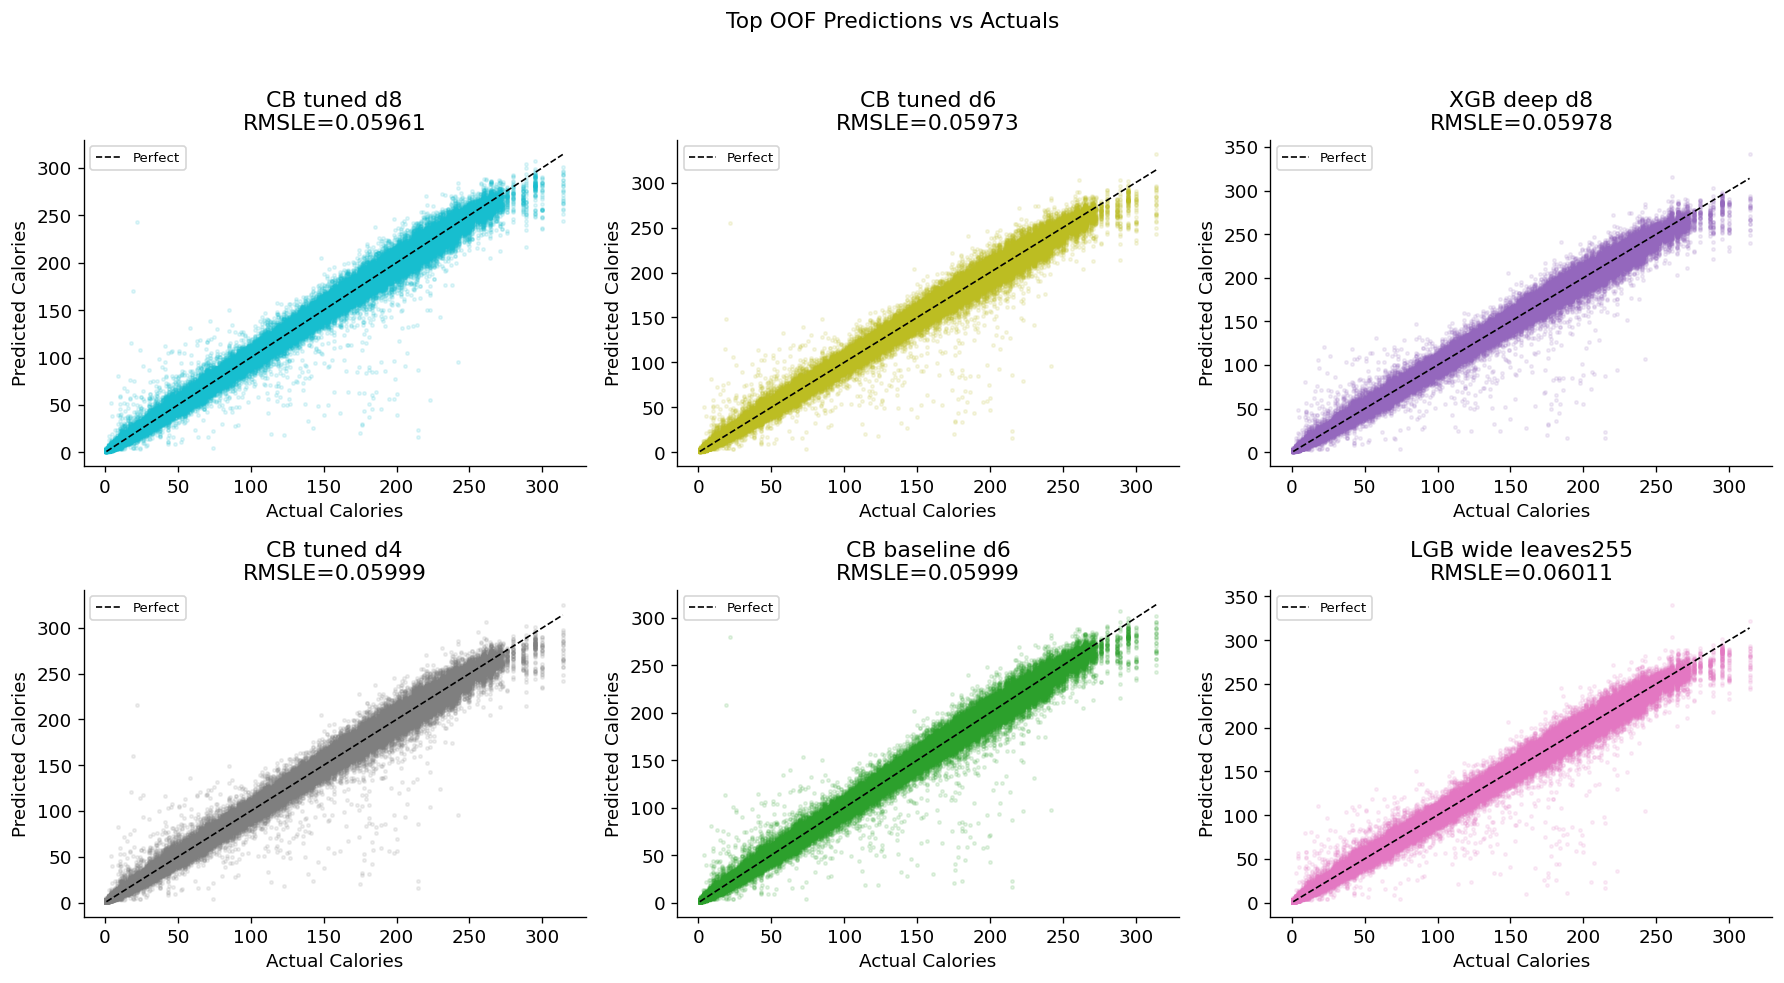

In [22]:
# --- OOF scatter: predicted vs actual ------------------------------------
top_models = ordered_models[:min(6, len(ordered_models))]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flat

for ax, name in zip(axes, top_models):
    idx = models.index(name)
    oof = model_results[idx]['oof']
    ax.scatter(y, oof, alpha=0.12, s=4, color=model_palette[idx])
    lim = [y.min(), y.max()]
    ax.plot(lim, lim, 'k--', linewidth=1.0, label='Perfect')
    ax.set_xlabel('Actual Calories')
    ax.set_ylabel('Predicted Calories')
    ax.set_title(f'{name}\nRMSLE={rmsle(y, oof):.5f}')
    ax.legend(fontsize=8)

for ax in axes[len(top_models):]:
    ax.axis('off')

plt.suptitle('Top OOF Predictions vs Actuals', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


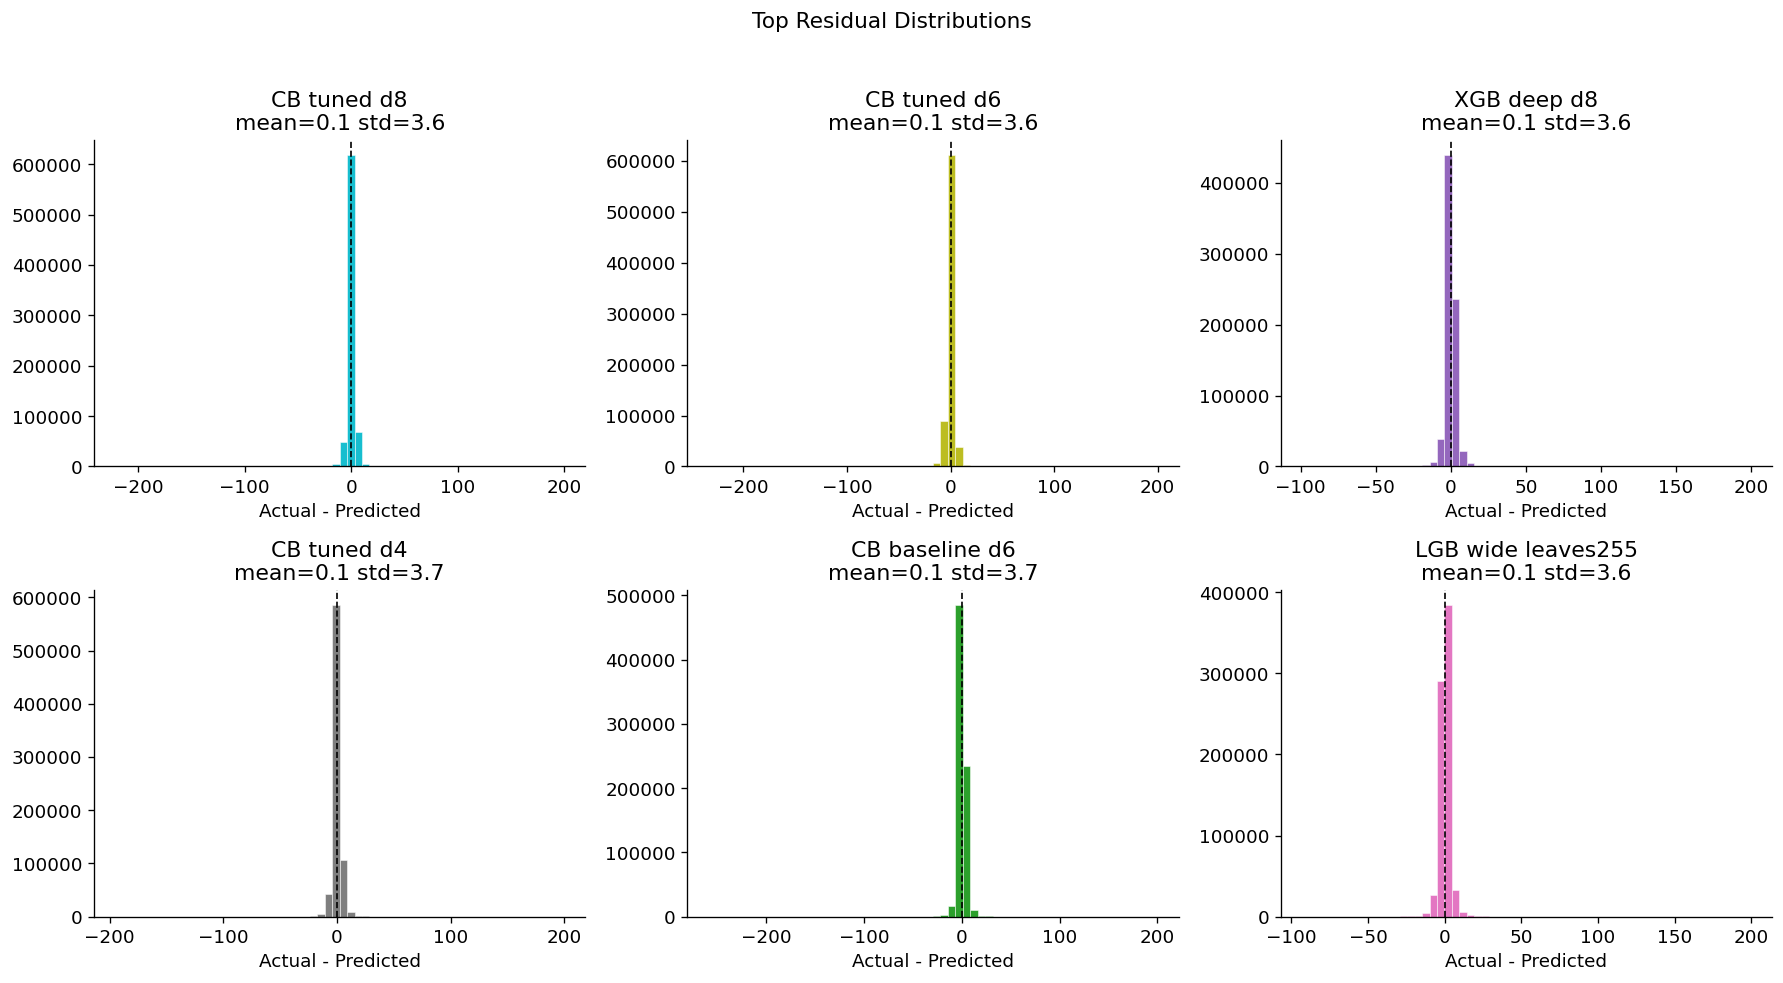

In [23]:
# --- Residual distributions ----------------------------------------------
top_models = ordered_models[:min(6, len(ordered_models))]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flat

for ax, name in zip(axes, top_models):
    idx = models.index(name)
    oof = model_results[idx]['oof']
    resid = y - oof
    ax.hist(resid, bins=60, color=model_palette[idx], edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='black', linewidth=1.0, linestyle='--')
    ax.set_title(f'{name}\nmean={resid.mean():.1f} std={resid.std():.1f}')
    ax.set_xlabel('Actual - Predicted')

for ax in axes[len(top_models):]:
    ax.axis('off')

plt.suptitle('Top Residual Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


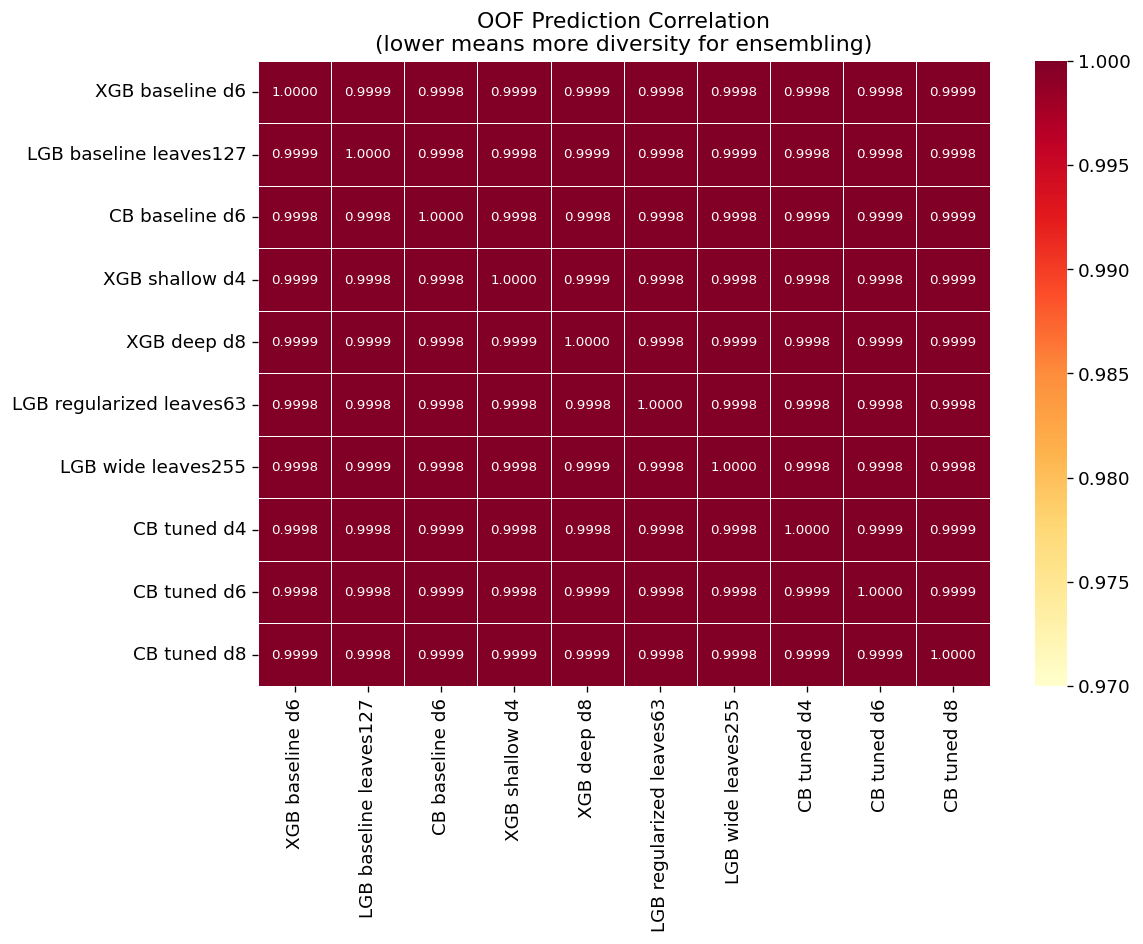

In [24]:
# --- OOF prediction correlation ------------------------------------------
oof_df = pd.DataFrame(oof_matrix, columns=models)
corr_oof = oof_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_oof,
    annot=True,
    fmt='.4f',
    cmap='YlOrRd',
    vmin=0.97,
    vmax=1.0,
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 8},
)
ax.set_title('OOF Prediction Correlation\n(lower means more diversity for ensembling)')
plt.tight_layout()
plt.show()


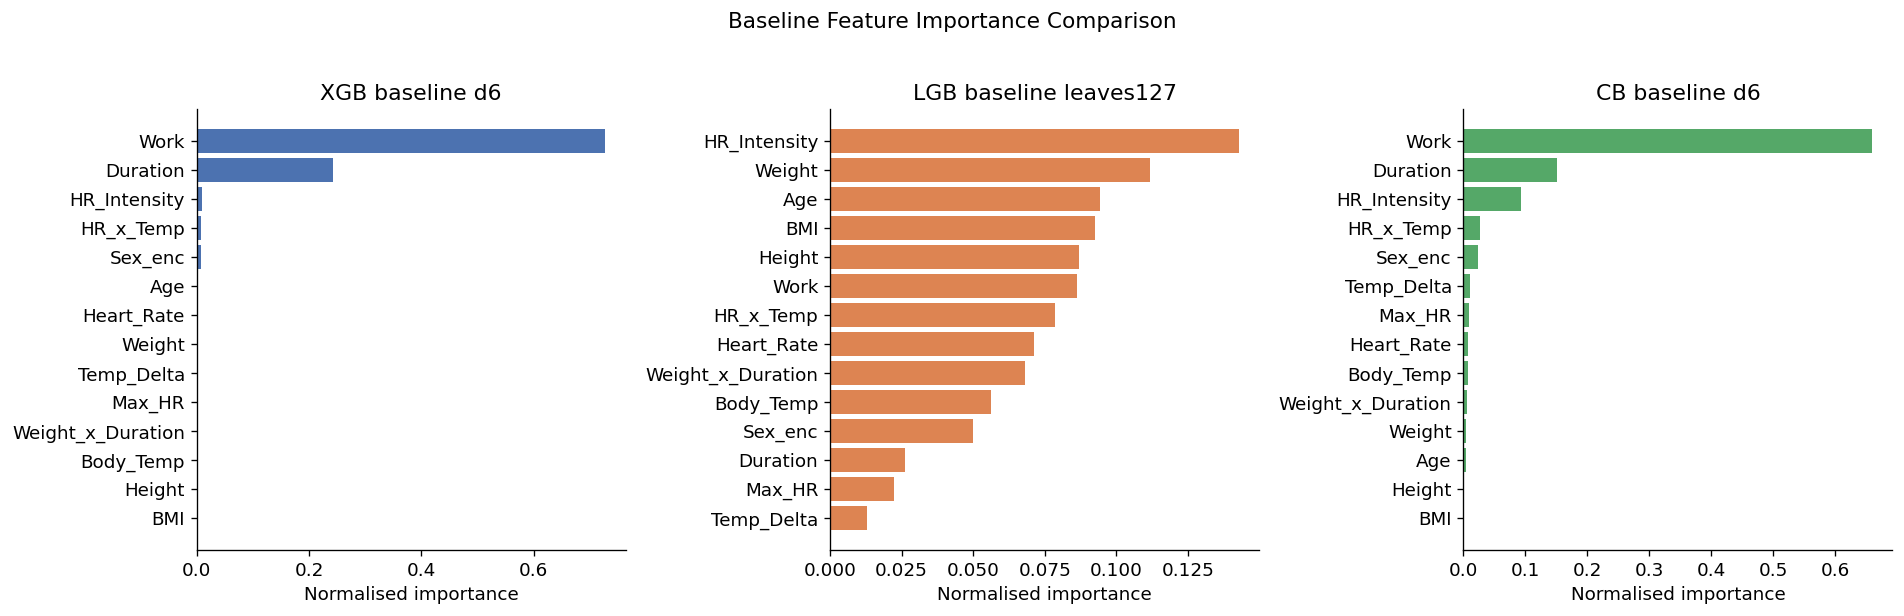

In [25]:
# --- Baseline feature importance: side-by-side normalised ----------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, imp, name, color in zip(
    axes,
    [xgb_imp, lgb_imp, cb_imp],
    ['XGB baseline d6', 'LGB baseline leaves127', 'CB baseline d6'],
    PALETTE,
):
    norm = imp['importance'] / imp['importance'].sum()
    ax.barh(imp['feature'], norm, color=color)
    ax.set_title(name)
    ax.set_xlabel('Normalised importance')

plt.suptitle('Baseline Feature Importance Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [26]:
# --- Simple average ensemble ---------------------------------------------
ensemble_oof = oof_matrix.mean(axis=1)
ensemble_test = test_matrix.mean(axis=1)

best_solo_score = summary['CV RMSLE'].min()
best_solo_name = summary.index[0]
ens_score = rmsle(y, ensemble_oof)

print('=== Initial Ensemble Check ===')
print(f'  Best solo ({best_solo_name}) OOF RMSLE : {best_solo_score:.5f}')
print(f'  Simple average OOF RMSLE              : {ens_score:.5f}')
print(f'\n  Improvement vs best solo: {best_solo_score - ens_score:+.5f}')


=== Initial Ensemble Check ===
  Best solo (CB tuned d8) OOF RMSLE : 0.05961
  Simple average OOF RMSLE              : 0.05929

  Improvement vs best solo: +0.00032


#### **O-Fold Stacking (Ridge Meta-Learner)**

Instead of a simple average, we use a **Ridge Regressor** as a meta-learner. 
It learns the optimal linear combination of our three models' predictions based on their Out-of-Fold (OOF) performance.

In [27]:
# --- 1. Meta-features ----------------------------------------------------
# Work in log-space because RMSLE is RMSE on log1p(Calories).
meta_X_train = oof_matrix
meta_X_test = test_matrix

meta_train = np.log1p(np.clip(meta_X_train, 0, None))
meta_test = np.log1p(np.clip(meta_X_test, 0, None))
meta_feature_names = model_names


In [28]:
# --- 2. Candidate ensembles evaluated with the same CV metric ------------
def search_blend_weights(y_true, pred_matrix, n_trials=5000, seed=SEED):
    """Search non-negative weights that sum to 1 for any number of base models."""
    rng = np.random.default_rng(seed)
    n_models = pred_matrix.shape[1]

    candidates = [np.full(n_models, 1 / n_models)]
    candidates.extend(np.eye(n_models))

    # Dirichlet samples give deterministic random convex blends without an
    # exponential grid search as the number of models grows.
    candidates.extend(rng.dirichlet(np.ones(n_models), size=n_trials))

    best_score = np.inf
    best_weights = candidates[0]
    for weights in candidates:
        blended = pred_matrix @ weights
        score = rmsle(y_true, blended)
        if score < best_score:
            best_score = score
            best_weights = weights

    return best_weights, best_score


simple_avg_oof = meta_X_train.mean(axis=1)
simple_avg_test = meta_X_test.mean(axis=1)
simple_avg_score = rmsle(y, simple_avg_oof)

best_single_idx = int(np.argmin([rmsle(y, m['oof']) for m in model_results]))
best_single_oof = model_results[best_single_idx]['oof']
best_single_test = model_results[best_single_idx]['test']
best_single_score = rmsle(y, best_single_oof)

ridge_alpha = 0.1
stack_oof = np.zeros(len(X))
stack_scores = []

blend_oof = np.zeros(len(X))
blend_scores = []
fold_blend_weights = []

for fold, (train_idx, val_idx) in enumerate(FOLDS):
    X_meta_tr, X_meta_val = meta_train[train_idx], meta_train[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    ridge = Ridge(alpha=ridge_alpha, positive=True)
    ridge.fit(X_meta_tr, np.log1p(y_tr))

    stack_pred = np.clip(np.expm1(ridge.predict(X_meta_val)), 0, None)
    stack_oof[val_idx] = stack_pred
    stack_scores.append(rmsle(y_val, stack_pred))

    weights, _ = search_blend_weights(y_tr, meta_X_train[train_idx], n_trials=5000, seed=SEED + fold)
    blend_pred = np.clip(meta_X_train[val_idx] @ weights, 0, None)
    blend_oof[val_idx] = blend_pred
    blend_scores.append(rmsle(y_val, blend_pred))
    fold_blend_weights.append(weights)

    nonzero = pd.Series(weights, index=model_names).sort_values(ascending=False).head(5)
    print(
        f'Fold {fold + 1}: '
        f'Ridge RMSLE={stack_scores[-1]:.5f} | '
        f'Blend RMSLE={blend_scores[-1]:.5f} | '
        f'top weights={nonzero.round(3).to_dict()}'
    )


Fold 1: Ridge RMSLE=0.05912 | Blend RMSLE=0.05909 | top weights={'CB tuned d8': 0.22, 'XGB deep d8': 0.168, 'CB tuned d6': 0.15, 'LGB wide leaves255': 0.146, 'CB tuned d4': 0.123}
Fold 2: Ridge RMSLE=0.05976 | Blend RMSLE=0.05979 | top weights={'CB tuned d4': 0.199, 'XGB deep d8': 0.182, 'CB tuned d8': 0.175, 'LGB wide leaves255': 0.175, 'CB tuned d6': 0.107}
Fold 3: Ridge RMSLE=0.05911 | Blend RMSLE=0.05909 | top weights={'XGB deep d8': 0.264, 'CB tuned d8': 0.207, 'CB tuned d6': 0.181, 'CB baseline d6': 0.101, 'LGB wide leaves255': 0.095}
Fold 4: Ridge RMSLE=0.05946 | Blend RMSLE=0.05955 | top weights={'CB tuned d8': 0.265, 'XGB deep d8': 0.219, 'LGB wide leaves255': 0.163, 'CB tuned d4': 0.112, 'LGB regularized leaves63': 0.094}
Fold 5: Ridge RMSLE=0.05891 | Blend RMSLE=0.05891 | top weights={'XGB deep d8': 0.201, 'CB tuned d6': 0.181, 'CB tuned d8': 0.14, 'LGB wide leaves255': 0.102, 'CB baseline d6': 0.102}


In [29]:
# --- 3. Fit final candidates on all OOF predictions ----------------------
final_ridge = Ridge(alpha=ridge_alpha, positive=True)
final_ridge.fit(meta_train, np.log1p(y))
stack_test_preds = np.clip(np.expm1(final_ridge.predict(meta_test)), 0, None)

final_blend_weights, _ = search_blend_weights(y, meta_X_train, n_trials=10000, seed=SEED)
blend_test_preds = np.clip(meta_X_test @ final_blend_weights, 0, None)

candidate_scores = {
    'best_single': best_single_score,
    'simple_average': simple_avg_score,
    'ridge_stack': rmsle(y, stack_oof),
    'weighted_blend': rmsle(y, blend_oof),
}

best_ensemble_name = min(candidate_scores, key=candidate_scores.get)
best_ensemble_score = candidate_scores[best_ensemble_name]

final_test_preds = {
    'best_single': best_single_test,
    'simple_average': simple_avg_test,
    'ridge_stack': stack_test_preds,
    'weighted_blend': blend_test_preds,
}[best_ensemble_name]

print('\n=== Ensemble Comparison (OOF RMSLE) ===')
print(f'Best single    : {best_single_score:.5f}  ({model_results[best_single_idx]["name"]})')
print(f'Simple average : {simple_avg_score:.5f}')
print(f'Ridge stack    : {candidate_scores["ridge_stack"]:.5f} +/- {np.std(stack_scores):.5f}')
print(f'Weighted blend : {candidate_scores["weighted_blend"]:.5f} +/- {np.std(blend_scores):.5f}')
print(f'\nSelected ensemble: {best_ensemble_name} | RMSLE={best_ensemble_score:.5f}')

print('\n--- Ridge coefficients (log-space stacker) ---')
print(pd.Series(final_ridge.coef_, index=meta_feature_names).sort_values(ascending=False))

print('\n--- Weighted blend coefficients ---')
print(pd.Series(final_blend_weights, index=model_names).sort_values(ascending=False))



=== Ensemble Comparison (OOF RMSLE) ===
Best single    : 0.05961  (CB tuned d8)
Simple average : 0.05929
Ridge stack    : 0.05928 +/- 0.00030
Weighted blend : 0.05929 +/- 0.00033

Selected ensemble: ridge_stack | RMSLE=0.05928

--- Ridge coefficients (log-space stacker) ---
XGB deep d8                 0.197684
CB tuned d8                 0.193700
LGB wide leaves255          0.141635
CB tuned d6                 0.140166
CB baseline d6              0.132994
CB tuned d4                 0.098462
LGB regularized leaves63    0.059815
XGB baseline d6             0.029028
LGB baseline leaves127      0.006603
XGB shallow d4              0.000000
dtype: float64

--- Weighted blend coefficients ---
CB tuned d8                 0.190847
CB tuned d6                 0.187681
LGB wide leaves255          0.162067
XGB deep d8                 0.143154
CB baseline d6              0.074149
CB tuned d4                 0.071899
LGB baseline leaves127      0.066744
XGB baseline d6             0.054056
LGB re

In [30]:
# --- Save submission ------------------------------------------------------
submission = pd.DataFrame({
    'id':       test['id'],
    'Calories': final_test_preds
})
submission.to_csv('submission_stacked.csv', index=False)
print(f'submission_stacked.csv saved using: {best_ensemble_name}')
submission.head()

submission_stacked.csv saved using: ridge_stack


,id,Calories
0,750000,27.385337
1,750001,108.778612
2,750002,86.927615
3,750003,125.199720
4,750004,75.946946


#### **Key Takeaways**

| | XGBoost | LightGBM | CatBoost |
|---|---|---|---|
| **Tree growth** | Level-wise | Leaf-wise | Symmetric (oblivious) |
| **Speed** | Medium | Fastest | Slowest |
| **Tuning effort** | High | Medium | Low-to-medium after depth/lr search |
| **Categoricals** | Manual encode | Native | Native |
| **Best for** | Max control | Large data | Strong tuned tabular baseline |

**Changes in this stacked version:**
- Added diverse XGBoost and LightGBM variants with different depth, leaf count, regularisation, feature sampling, and seeds.
- Added a CatBoost tuning pass with `3000` iterations, lower learning rates, longer early stopping, and depths `4`, `6`, and `8`.
- Refactored comparison and stacking to use all available model variants instead of only the original three.

**Next steps:**
- If runtime is high, keep only variants with competitive OOF RMSLE or non-trivial blend weights.
- Add leakage-safe exact-match/group-mean features for duplicate physiological rows.
- Blend the original public dataset with the synthetic Playground data if competition rules allow it.
